# Try PathFinder on Retinotopy data

Use task (retinotopy) data with different stimuli to jointly model brain response and stimuli, and use PathFinder principle to predict stimulus.


In [32]:
# -- here while dev in progress
import importlib
importlib.reload(utils)
importlib.reload(decomp)
# ---

<module 'pathfinder.decomp' from '/opt/miniconda3/envs/py38/lib/python3.8/site-packages/pathfinder/decomp.py'>

In [3]:
# Load stimuli
import numpy as np
npzfile = np.load('../pathfinder/data/retino.npz')

stims_names = sorted(npzfile.files)
stims       = [  npzfile[name] for name in stims_names ]

In [5]:
# Visualise stimuli
# HELPER FUNCTION
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def animate(X):
    """ X is a 3D array with time as first dimension
    """
    T = X.shape[0]    
    fig, ax = plt.subplots()
    plt.close()

    ims = []
    for i in range(T):    
        im = ax.imshow(X[i], animated=True)
        ims.append([im])

    ani = animation.ArtistAnimation(fig, ims, interval=20, blit=True, repeat_delay=1000)

    return HTML(ani.to_html5_video())


In [6]:
# Look at stimuli

animate(stims[0])


In [7]:
# Generate Retinotopy data using PRF modelling

from numba import njit, prange

@njit(parallel=True)
def calc_sG(s, x, y, x0, y0, sig):
    """ calculate s*G(xy, xy0) by parallelizing over xy0
    """
    s = np.reshape(s, (s.shape[0],-1) )
    x, y, x0, y0 = x.flatten(), y.flatten(), x0.flatten(), y0.flatten()
    ret = np.zeros((s.shape[0], len(x0)))
    for i in prange(len(x0)):
        w_i = np.exp(-((x-x0[i])**2 + (y-y0[i])**2)/2./sig**2)
        ret[:,i] = s @ w_i / np.sum(w_i)
    return ret
    

def prf( stim, x0, y0, sig ):
    """stim->neural activity
    stim      : 3D array of size T-times-(N_x-times-N_y)
    x0,y0,sig : 1D array of receptive fields
    """
    nx, ny = stim.shape[1:]
    x,  y  = np.linspace(-1, 1, nx), np.linspace(-1, 1, ny)
    xv, yv = np.meshgrid(x, y, indexing='ij')
    
    # G is (NxNy)x(N) - too big?
    # G = np.exp(-(np.subtract.outer(xv, x0.flatten())**2 + np.subtract.outer(yv, y0.flatten())**2)/sig**2/2.)        
    sG = calc_sG(stim, xv, yv, x0, y0, sig)
    return np.reshape(sG, (sG.shape[0],x0.shape[0],x0.shape[1]))


In [8]:
# 2D model of V1 (as a square)
V1_x0, V1_y0 = np.meshgrid( np.linspace(-1, 1, 50), np.linspace(-1, 1, 50) , indexing='ij')
sig          = .1

from tqdm import tqdm
Brain_data = []
for s in tqdm(stims):
    r = prf( s, V1_x0, V1_y0, sig )
    Brain_data.append(r)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.08s/it]


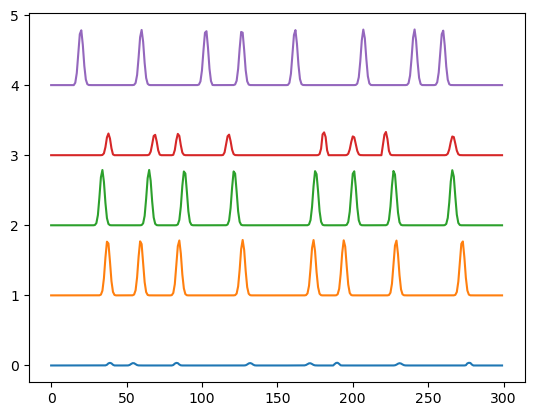

In [20]:
# Look at the data
stim_id = 0
data    = Brain_data[stim_id]

import matplotlib.pyplot as plt
idx = [np.random.randint(50*50) for i in range(5)]
for i, j in enumerate(idx):    
    plt.plot(i+data.reshape((300,-1))[:,j])
plt.show()


In [44]:
# Organise for PathFinder

PRF_Data          = { 'Stim' : {}, 'Brain' : {} }
PRF_Data_complete = { 'Stim' : {}, 'Brain' : {} }

for i, c in enumerate(stims_names):
    PRF_Data_complete['Stim'][c]  = stims[i].reshape((300,-1)).T
    PRF_Data_complete['Brain'][c] = Brain_data[i].reshape((300,-1)).T
    
    PRF_Data['Stim'][c]  = stims[i].reshape((300,-1)).T
    PRF_Data['Brain'][c] = Brain_data[i].reshape((300,-1)).T

PRF_Data['Stim']['RETCCW'] = None


In [59]:
from pathfinder import decomp

from sklearn.linear_model import Ridge
algo = decomp.JointDecomp(n_components=10, n_iter=10, dropout=-1, 
                          method=Ridge, method_kwargs={'alpha':1e2})
A, S, err = algo.fit(PRF_Data)


100%|████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:29<00:00,  2.95s/it]


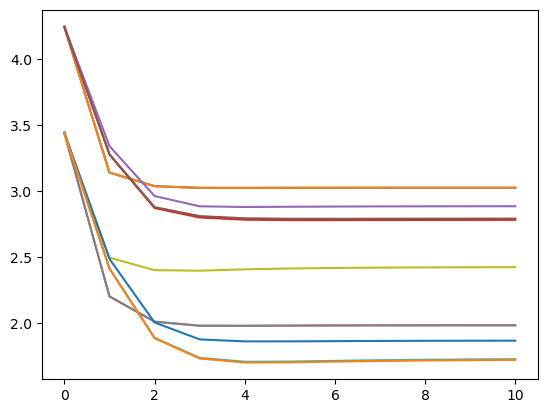

In [60]:
# Look at error / convergence
from pathfinder import utils

_ = utils.plot_error(err)

In [62]:

PRF_Data_Pred = utils.predicted_data_grid(PRF_Data, A, S)

name = 'RETCCW'
nx, ny = stims[stims_names.index(name)].shape[1:]
X = PRF_Data_Pred['Stim'][name]
x = np.reshape(X.T, (-1, nx, ny ) )
animate(x)


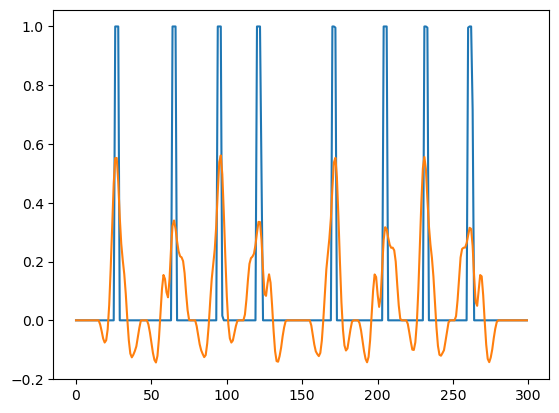

In [70]:
name = 'RETBAR1'

nx, ny = stims[stims_names.index(name)].shape[1:]
X      = PRF_Data_complete['Stim'][name].T.reshape((300,nx,ny))
X_pred = PRF_Data_Pred['Stim'][name].T.reshape((300,nx,ny))

plt.figure()
plt.plot(X[:,100,150])
plt.plot(X_pred[:,100,150])
plt.show()


## Now let's have a go at real retinotopy data

Data is from HCP 7T - averaged across 100+ subjects.